In [1]:
import joblib
import numpy as np
import time
import os
import pandas as pd
from itertools import combinations
from scipy.stats import mode
import warnings
# 모든 FutureWarning(버전 변경 예정 경고) 무시
warnings.simplefilter(action='ignore', category=FutureWarning)

# Scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin

# 이미지 처리
from scipy.ndimage import center_of_mass, shift, zoom

In [2]:
# =========================================================
# 1. 헬퍼 클래스 정의
# =========================================================
# ==========================================
# 1. 사용자 정의 전처리 클래스
# ==========================================
class CustomImagePreprocess(BaseEstimator, TransformerMixin):
    def __init__(self, stroke_target=0.4, target_size=20, final_size=28, noise_threshold=0.02):
        self.stroke_target = stroke_target       
        self.target_size = target_size           
        self.final_size = final_size             
        self.noise_threshold = noise_threshold   
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X, y=None):
        X = np.array(X)
        if X.ndim == 2:
            side = int(np.sqrt(X.shape[1]))
            X = X.reshape(-1, side, side)
        
        processed = []
        for img in X:
            img = self.normalize_scale(img)   
            img = self.remove_noise(img)      
            img = self.normalize_stroke(img)  
            img = self.normalize_size(img)    
            img = self.center_align(img)
            processed.append(img)
        
        processed = np.array(processed)
        return processed.reshape(len(processed), -1)
    
    # --- 내부 메서드 ---
    def normalize_scale(self, img):
        img = img.astype(np.float32)
        if img.max() > 1: img = img / 255.0
        return img
    
    def remove_noise(self, img):
        img = img.copy()
        img[img < self.noise_threshold] = 0.0
        return img
    
    def normalize_stroke(self, img):
        mask = img > 0.05
        if mask.sum() == 0: return img
        mean_val = img[mask].mean()
        if mean_val == 0: return img
        scale_factor = self.stroke_target / mean_val
        img = img * scale_factor
        img = np.clip(img, 0, 1)
        return img
    
    def normalize_size(self, img):
        coords = np.where(img > 0.05)
        if coords[0].size == 0: return np.zeros((self.final_size, self.final_size))
        r1, r2 = coords[0].min(), coords[0].max()
        c1, c2 = coords[1].min(), coords[1].max()
        digit = img[r1:r2+1, c1:c2+1]
        h, w = digit.shape
        if h == 0 or w == 0: return np.zeros((self.final_size, self.final_size))
        zoom_h = self.target_size / h
        zoom_w = self.target_size / w
        digit_resized = zoom(digit, (zoom_h, zoom_w))
        return digit_resized
    
    def center_align(self, img):
        canvas = np.zeros((self.final_size, self.final_size))
        h, w = img.shape
        if h > self.final_size or w > self.final_size:
            h_start = (h - self.final_size) // 2
            w_start = (w - self.final_size) // 2
            img = img[h_start:h_start+self.final_size, w_start:w_start+self.final_size]
            h, w = img.shape
        y0 = (self.final_size - h) // 2
        x0 = (self.final_size - w) // 2
        canvas[y0:y0+h, x0:x0+w] = img
        return canvas

class ForceFittedClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator):
        self.estimator = estimator
    def fit(self, X, y=None): return self
    def predict(self, X): return self.estimator.predict(X)
    def predict_proba(self, X): return self.estimator.predict_proba(X)
    def __sklearn_is_fitted__(self): return True

class PreFittedVotingClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, estimators, voting='soft'):
        self.estimators = estimators
        self.voting = voting
        
    def fit(self, X, y): return self
    
    def predict(self, X):
        if self.voting == 'soft':
            probas = self.predict_proba(X)
            return np.argmax(probas, axis=1)
        else: # hard voting
            predictions = np.zeros((X.shape[0], len(self.estimators)), dtype=int)
            for i, (_, model) in enumerate(self.estimators):
                predictions[:, i] = model.predict(X)
            try:
                majority_vote = mode(predictions, axis=1, keepdims=True).mode.flatten()
            except TypeError:
                majority_vote = mode(predictions, axis=1).mode.flatten()
            return majority_vote
    
    def predict_proba(self, X):
        if self.voting == 'hard':
            raise AttributeError("predict_proba is not available when voting='hard'")
        avg_proba = None
        count = 0
        for _, model in self.estimators:
            try:
                proba = model.predict_proba(X)
                if avg_proba is None: avg_proba = proba
                else: avg_proba += proba
                count += 1
            except: continue
        return avg_proba / count if count > 0 else avg_proba

In [3]:
# =========================================================
# 2. 데이터 로드
# =========================================================
def load_data_simple(hand_path, org_path):
    print("📂 Loading Data...")
    if not os.path.exists(hand_path) or not os.path.exists(org_path):
        return None, None, None, None
    d_hand = np.load(hand_path, allow_pickle=True)
    X_hand, y_hand = d_hand['x_train'], d_hand['y_train'].astype(int)
    d_org = np.load(org_path, allow_pickle=True)
    X_org, y_org = d_org['x_train'], d_org['y_train'].astype(int)
    
    if X_hand.ndim == 3: X_hand = X_hand.reshape(len(X_hand), -1)
    if X_org.ndim == 3: X_org = X_org.reshape(len(X_org), -1)
    X = np.concatenate([X_hand, X_org])
    y = np.concatenate([y_hand, y_org])
    if X.max() > 1.0: X = X.astype(np.float32) / 255.0
        
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
# =========================================================
# 3. 메인 실행 코드
# =========================================================
if __name__ == "__main__":
    hand_file = '../data/final/mnist_final_balanced.npz'
    org_file = '../data/final/mnist_sklearn_40000.npz'
    X_train, X_test, y_train, y_test = load_data_simple(hand_file, org_file)

    if X_train is not None:
        # 1. Base 모델 5개 정의 (파일 경로 확인 필수!)
        model_paths = {
            'mlp': 'pipeline/base/mlp_HandAug_4x.joblib',
            'rf':  'pipeline/base/pipeline_model_HandAug_4x_Preprocessed_rf.pkl',
            'knn': 'pipeline/base/pipeline_knn_model_HandAug_4x_Preprocessed_KNN.pkl',
            'gb':  'pipeline/base/pipeline_model_HandAug_1x_Preprocessed_gb.pkl',
            # 'svm': 'pipeline/pipeline_svm_HandAug_4x_Preprocessed_SVM.joblib' # SVM 경로 확인 필요
        }
        
        # 2. 모델 로드 및 래핑
        loaded_estimators = {}
        print("\n📂 Loading Base Models...")
        for name, path in model_paths.items():
            if os.path.exists(path):
                try:
                    loaded_model = joblib.load(path)
                    wrapped_model = ForceFittedClassifier(loaded_model)
                    loaded_estimators[name] = wrapped_model
                    print(f"  > Loaded & Wrapped: {name}")
                except Exception as e:
                    print(f"  [Error] Failed to load {name}: {e}")
            else:
                print(f"  [Warning] File not found: {path} (Skipping {name})")
        
        available_models = list(loaded_estimators.items()) # [('mlp', model), ('rf', model), ...]
        
        # =========================================================================
        # 3. 메타 모델 설정 (6가지)
        # =========================================================================
        meta_configs = {
            'Logistic': {
                'model': LogisticRegression(random_state=42, max_iter=1000),
                'params': {'C': [0.1, 1.0, 10.0], 'solver': ['lbfgs', 'liblinear']}
            },
            'DecisionTree': {
                'model': DecisionTreeClassifier(random_state=42),
                'params': {'max_depth': [3, 4], 'min_samples_leaf': [10, 20]}
            },
            'KNN': {
                'model': KNeighborsClassifier(),
                'params': {'n_neighbors': [9, 15, 30], 'weights': ['uniform', 'distance']}
            }
        }

        if len(available_models) >= 3:
            results = []
            
            print("\n" + "="*60)
            print("🚀 Starting Combinations Experiment (Stacking 6 Meta & Voting)")
            print(f"   Base Models Available: {len(available_models)} ({[n for n, _ in available_models]})")
            print("="*60)

            # 4. 조합 생성 (3개 ~ 5개)
            min_k, max_k = 3, 5
            
            for k in range(min_k, min(max_k, len(available_models)) + 1):
                for combo in combinations(available_models, k):
                    # combo는 (('mlp', model), ('rf', model), ...) 형태의 튜플
                    combo_names = "+".join([name for name, _ in combo])
                    estimators_list = list(combo)
                    
                    print(f"\n[{k} Models Combo] {combo_names}")
                    
                    # -----------------------------------------------------
                    # (A) Stacking: Meta-Features 생성 (1회)
                    # -----------------------------------------------------
                    try:
                        # 임시 스태킹 모델로 transform 수행 -> Meta Features 추출
                        temp_stack = StackingClassifier(estimators=estimators_list, final_estimator=LogisticRegression(), cv='prefit', n_jobs=-1)
                        temp_stack.fit(X_train, y_train)
                        X_meta_train = temp_stack.transform(X_train)
                        
                        # (A-1) 6가지 Meta Model 실험
                        for meta_name, config in meta_configs.items():
                            # print(f"  -> Tuning Stacking Meta: {meta_name}...", end=" ")
                            
                            # GridSearchCV로 메타 모델 튜닝
                            grid = GridSearchCV(config['model'], config['params'], cv=3, scoring='accuracy', n_jobs=-1)
                            start = time.time()
                            grid.fit(X_meta_train, y_train)
                            elapsed = time.time() - start
                            
                            best_meta = grid.best_estimator_
                            
                            # 최종 Stacking 모델 생성
                            final_stack = StackingClassifier(
                                estimators=estimators_list,
                                final_estimator=best_meta,
                                cv='prefit',
                                n_jobs=-1
                            )
                            final_stack.fit(X_train, y_train)
                            acc = final_stack.score(X_test, y_test)
                            
                            print(f"Acc: {acc*100:.2f}% ({elapsed:.1f}s)")
                            
                            # 저장 및 기록
                            fname = f"stacking_{combo_names}_{meta_name}.joblib"
                            joblib.dump(final_stack, fname) # 필요시 주석 해제 (파일 너무 많음 주의)
                            
                            results.append({
                                'Type': 'Stacking',
                                'Base Models': combo_names,
                                'Meta Model': meta_name,
                                'Accuracy': acc,
                                'Time': elapsed
                            })

                    except Exception as e:
                        print(f"  [Error] Stacking failed for {combo_names}: {e}")

                    # -----------------------------------------------------
                    # (B) Voting (Soft & Hard)
                    # -----------------------------------------------------
                    for v_type in ['soft', 'hard']:
                        try:
                            # print(f"  -> Voting ({v_type})...", end=" ")
                            voting_clf = PreFittedVotingClassifier(estimators_list, voting=v_type)
                            voting_clf.fit(X_train, y_train)
                            
                            start = time.time()
                            acc_vote = accuracy_score(y_test, voting_clf.predict(X_test))
                            elapsed = time.time() - start
                            
                            print(f"Acc: {acc_vote*100:.2f}%")
                            
                            fname = f"voting_{v_type}_{combo_names}.joblib"
                            joblib.dump(voting_clf, fname)
                            
                            results.append({
                                'Type': f'Voting ({v_type})',
                                'Base Models': combo_names,
                                'Meta Model': '-',
                                'Accuracy': acc_vote,
                                'Time': elapsed
                            })
                        except Exception as e:
                            print(f"  [Error] Voting {v_type} failed: {e}")

            # 5. 결과 요약 및 저장
            print("\n" + "="*60)
            print("🏆 Top 20 Best Ensemble Results")
            print("="*60)
            df_res = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
            print(df_res.head(20))
            
            df_res.to_csv("ensemble_experiment_results.csv", index=False)
            print("\n  > Full results saved to 'ensemble_experiment_results.csv'")
            
            # (선택) 1등 모델 저장
            if len(df_res) > 0:
                best_row = df_res.iloc[0]
                print(f"\n🥇 Best Model: {best_row['Type']} | Base: {best_row['Base Models']} | Meta: {best_row['Meta Model']} ({best_row['Accuracy']*100:.2f}%)")
                # 여기서 1등 모델만 다시 빌드해서 저장하는 로직을 추가할 수도 있습니다.
                
        else:
            print(f"\n[Error] 로드된 모델이 {len(available_models)}개입니다. 최소 3개가 필요합니다.")

📂 Loading Data...

📂 Loading Base Models...
  [Error] Failed to load mlp: Can't get attribute 'CustomImagePreprocess' on <module '__main__'>
  [Error] Failed to load rf: Can't get attribute 'CustomImagePreprocess' on <module '__main__'>
  [Error] Failed to load knn: Can't get attribute 'CustomImagePreprocess' on <module '__main__'>
  [Error] Failed to load gb: Can't get attribute 'CustomImagePreprocess' on <module '__main__'>

[Error] 로드된 모델이 0개입니다. 최소 3개가 필요합니다.


In [5]:
import joblib
import numpy as np
import time
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mode
import warnings

# 경고 무시
warnings.simplefilter(action='ignore', category=FutureWarning)

# Scikit-learn
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.ndimage import zoom

# =========================================================
# [설정] 모델 조합 및 앙상블 방식
# =========================================================
SELECTED_MODELS = ['mlp', 'rf', 'knn'] 
ENSEMBLE_TYPE = 'stacking' 
# =========================================================

# ---------------------------------------------------------
# [핵심] 초기화 방지용 컨테이너 & 래퍼
# ---------------------------------------------------------

class CustomImagePreprocess(BaseEstimator, TransformerMixin):
    def __init__(self, stroke_target=0.4, target_size=20, final_size=28, noise_threshold=0.02):
        self.stroke_target = stroke_target       
        self.target_size = target_size           
        self.final_size = final_size             
        self.noise_threshold = noise_threshold   
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X, y=None):
        X = np.array(X)
        if X.ndim == 2:
            side = int(np.sqrt(X.shape[1]))
            X = X.reshape(-1, side, side)
        
        processed = []
        for img in X:
            img = self.normalize_scale(img)   
            img = self.remove_noise(img)      
            img = self.normalize_stroke(img)  
            img = self.normalize_size(img)    
            img = self.center_align(img)
            processed.append(img)
        
        processed = np.array(processed)
        return processed.reshape(len(processed), -1)
    
    # --- 내부 메서드 ---
    def normalize_scale(self, img):
        img = img.astype(np.float32)
        if img.max() > 1: img = img / 255.0
        return img
    
    def remove_noise(self, img):
        img = img.copy()
        img[img < self.noise_threshold] = 0.0
        return img
    
    def normalize_stroke(self, img):
        mask = img > 0.05
        if mask.sum() == 0: return img
        mean_val = img[mask].mean()
        if mean_val == 0: return img
        scale_factor = self.stroke_target / mean_val
        img = img * scale_factor
        img = np.clip(img, 0, 1)
        return img
    
    def normalize_size(self, img):
        coords = np.where(img > 0.05)
        if coords[0].size == 0: return np.zeros((self.final_size, self.final_size))
        r1, r2 = coords[0].min(), coords[0].max()
        c1, c2 = coords[1].min(), coords[1].max()
        digit = img[r1:r2+1, c1:c2+1]
        h, w = digit.shape
        if h == 0 or w == 0: return np.zeros((self.final_size, self.final_size))
        zoom_h = self.target_size / h
        zoom_w = self.target_size / w
        digit_resized = zoom(digit, (zoom_h, zoom_w))
        return digit_resized
    
    def center_align(self, img):
        canvas = np.zeros((self.final_size, self.final_size))
        h, w = img.shape
        if h > self.final_size or w > self.final_size:
            h_start = (h - self.final_size) // 2
            w_start = (w - self.final_size) // 2
            img = img[h_start:h_start+self.final_size, w_start:w_start+self.final_size]
            h, w = img.shape
        y0 = (self.final_size - h) // 2
        x0 = (self.final_size - w) // 2
        canvas[y0:y0+h, x0:x0+w] = img
        return canvas

class ModelContainer:
    """
    sklearn의 clone() 함수가 내부 모델을 초기화(Reset)하지 못하도록 보호하는 컨테이너입니다.
    """
    def __init__(self, model):
        self.model = model

class ForceFittedClassifier(BaseEstimator, ClassifierMixin):
    """
    ModelContainer에 담긴 학습된 모델을 꺼내서 사용하는 래퍼입니다.
    fit()을 호출해도 아무 일도 하지 않으며(Skip),
    이미 학습된 모델로 predict()만 수행합니다.
    """
    def __init__(self, wrapped_container):
        self.wrapped_container = wrapped_container

    def fit(self, X, y=None):
        # 학습 방지: 이미 학습되었으므로 아무것도 하지 않음
        return self

    def predict(self, X):
        return self.wrapped_container.model.predict(X)

    def predict_proba(self, X):
        return self.wrapped_container.model.predict_proba(X)
    
    def __sklearn_is_fitted__(self):
        return True

class PreFittedVotingClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, estimators, voting='soft'):
        self.estimators = estimators
        self.voting = voting
        
    def fit(self, X, y): return self
    
    def predict(self, X):
        if self.voting == 'soft':
            return np.argmax(self.predict_proba(X), axis=1)
        else:
            predictions = np.zeros((X.shape[0], len(self.estimators)), dtype=int)
            for i, (_, model) in enumerate(self.estimators):
                predictions[:, i] = model.predict(X)
            return mode(predictions, axis=1).mode.flatten()
    
    def predict_proba(self, X):
        if self.voting == 'hard': raise AttributeError("N/A for hard voting")
        avg_proba = None
        count = 0
        for _, model in self.estimators:
            try:
                p = model.predict_proba(X)
                if avg_proba is None: avg_proba = p
                else: avg_proba += p
                count += 1
            except: continue
        return avg_proba / count if count > 0 else avg_proba

# --- 데이터 로드 ---
def load_data_simple(hand_path, org_path):
    print("📂 Loading Data...")
    if not os.path.exists(hand_path) or not os.path.exists(org_path):
        return None, None, None, None
    d_hand = np.load(hand_path, allow_pickle=True)
    X_hand, y_hand = d_hand['x_train'], d_hand['y_train'].astype(int)
    d_org = np.load(org_path, allow_pickle=True)
    X_org, y_org = d_org['x_train'], d_org['y_train'].astype(int)
    
    if X_hand.ndim == 3: X_hand = X_hand.reshape(len(X_hand), -1)
    if X_org.ndim == 3: X_org = X_org.reshape(len(X_org), -1)
    X = np.concatenate([X_hand, X_org])
    y = np.concatenate([y_hand, y_org])
    if X.max() > 1.0: X = X.astype(np.float32) / 255.0
        
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 러닝 커브 (수정됨: n_jobs=1) ---
def plot_learning_curve_graph(estimator, title, X, y, cv=3):
    print(f"\n📊 Generating Learning Curve for: {title}")
    print("   (Processing SEQUENTIALLY to prevent memory crash... Please wait)")
    
    plt.figure(figsize=(10, 6))
    plt.title(f"Learning Curve ({title})")
    plt.xlabel("Training examples")
    plt.ylabel("Accuracy Score")
    
    # [수정] n_jobs=1 로 설정하여 메모리 폭발 방지
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=8, 
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='accuracy'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.grid()
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="CV score")
    plt.legend(loc="best")
    plt.show()

# =========================================================
# 메인 실행
# =========================================================
if __name__ == "__main__":
    hand_file = '../data/final/mnist_final_balanced.npz'
    org_file = '../data/final/mnist_sklearn_40000.npz'
    X_train, X_test, y_train, y_test = load_data_simple(hand_file, org_file)
    
    if X_train is not None:
        model_paths = {
            'mlp': 'pipeline/base/mlp_HandAug_4x.joblib',
            'rf':  'pipeline/base/pipeline_model_HandAug_4x_Preprocessed_rf.pkl',
            'knn': 'pipeline/base/pipeline_knn_model_HandAug_4x_Preprocessed_KNN.pkl',
            'gb':  'pipeline/base/pipeline_model_HandAug_1x_Preprocessed_gb.pkl',
        }
        
        # 1. 모델 로드 및 보호 (Protected Mode)
        estimators = []
        print(f"\n📂 Loading & Protecting Base Models: {SELECTED_MODELS}")
        
        for name in SELECTED_MODELS:
            path = model_paths.get(name)
            if path and os.path.exists(path):
                try:
                    loaded_raw = joblib.load(path)
                    
                    # [핵심] ModelContainer로 감싸서 clone 시 초기화 방지
                    container = ModelContainer(loaded_raw)
                    wrapped = ForceFittedClassifier(container)
                    
                    estimators.append((name, wrapped))
                    print(f"  > Loaded & Protected: {name}")
                except Exception as e:
                    print(f"  [Error] {name} 로드 실패: {e}")
        
        if len(estimators) < 2:
            print("⚠️ 모델이 2개 이상 필요합니다.")
        else:
            # 2. 앙상블 구성
            print(f"\n🛠️ Building Ensemble: {ENSEMBLE_TYPE.upper()}")
            
            if ENSEMBLE_TYPE == 'stacking':
                final_model = StackingClassifier(
                    estimators=estimators,
                    final_estimator=LogisticRegression(max_iter=1000),
                    cv='prefit', # Base Model 재학습 금지 (이미 학습됨)
                    n_jobs=1     # 여기서도 병렬처리 끄기
                )
            elif ENSEMBLE_TYPE.startswith('voting'):
                v_type = 'soft' if 'soft' in ENSEMBLE_TYPE else 'hard'
                final_model = PreFittedVotingClassifier(estimators, voting=v_type)
            
            # 3. 학습 (Meta Model만 학습됨)
            print("🚀 Training Meta-Model (Base Models are fixed)...")
            start_time = time.time()
            
            final_model.fit(X_train, y_train)
            
            fit_time = time.time() - start_time
            print(f"  > Done in {fit_time:.4f} seconds.")
            
            # 4. 평가
            print("\n📝 Evaluating...")
            y_pred = final_model.predict(X_test)
            
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, average='macro')
            rec = recall_score(y_test, y_pred, average='macro')
            f1 = f1_score(y_test, y_pred, average='macro')
            
            print("-" * 40)
            print(f"[{ENSEMBLE_TYPE.upper()}] Final Results")
            print("-" * 40)
            print(f"Accuracy    : {acc:.4f}")
            print(f"Precision   : {prec:.4f}")
            print(f"Recall      : {rec:.4f}")
            print(f"F1 Score    : {f1:.4f}")
            print(f"Fit Time    : {fit_time:.4f} sec")
            print("-" * 40)
            
            # 5. 러닝 커브
            if ENSEMBLE_TYPE == 'stacking':
                plot_learning_curve_graph(
                    final_model, 
                    f"{ENSEMBLE_TYPE} ({'+'.join(SELECTED_MODELS)})", 
                    X_train, 
                    y_train
                )
            else:
                print("[Info] Voting is purely inference-based (no training), skipping learning curve.")

📂 Loading Data...

📂 Loading & Protecting Base Models: ['mlp', 'rf', 'knn']
  > Loaded & Protected: mlp
  > Loaded & Protected: rf
  > Loaded & Protected: knn

🛠️ Building Ensemble: STACKING
🚀 Training Meta-Model (Base Models are fixed)...


KeyboardInterrupt: 

In [ ]:
import joblib
import numpy as np
import time
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mode
import warnings

# 경고 무시
warnings.simplefilter(action='ignore', category=FutureWarning)

# Scikit-learn
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.ndimage import zoom

# =========================================================
# [설정] 모델 조합 및 앙상블 방식
# =========================================================
SELECTED_MODELS = ['mlp', 'rf', 'knn'] 
ENSEMBLE_TYPE = 'voting_soft' 
# =========================================================

# ---------------------------------------------------------
# [핵심] 초기화 방지용 컨테이너 & 래퍼
# ---------------------------------------------------------

class CustomImagePreprocess(BaseEstimator, TransformerMixin):
    def __init__(self, stroke_target=0.4, target_size=20, final_size=28, noise_threshold=0.02):
        self.stroke_target = stroke_target       
        self.target_size = target_size           
        self.final_size = final_size             
        self.noise_threshold = noise_threshold   
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X, y=None):
        X = np.array(X)
        if X.ndim == 2:
            side = int(np.sqrt(X.shape[1]))
            X = X.reshape(-1, side, side)
        
        processed = []
        for img in X:
            img = self.normalize_scale(img)   
            img = self.remove_noise(img)      
            img = self.normalize_stroke(img)  
            img = self.normalize_size(img)    
            img = self.center_align(img)
            processed.append(img)
        
        processed = np.array(processed)
        return processed.reshape(len(processed), -1)
    
    # --- 내부 메서드 ---
    def normalize_scale(self, img):
        img = img.astype(np.float32)
        if img.max() > 1: img = img / 255.0
        return img
    
    def remove_noise(self, img):
        img = img.copy()
        img[img < self.noise_threshold] = 0.0
        return img
    
    def normalize_stroke(self, img):
        mask = img > 0.05
        if mask.sum() == 0: return img
        mean_val = img[mask].mean()
        if mean_val == 0: return img
        scale_factor = self.stroke_target / mean_val
        img = img * scale_factor
        img = np.clip(img, 0, 1)
        return img
    
    def normalize_size(self, img):
        coords = np.where(img > 0.05)
        if coords[0].size == 0: return np.zeros((self.final_size, self.final_size))
        r1, r2 = coords[0].min(), coords[0].max()
        c1, c2 = coords[1].min(), coords[1].max()
        digit = img[r1:r2+1, c1:c2+1]
        h, w = digit.shape
        if h == 0 or w == 0: return np.zeros((self.final_size, self.final_size))
        zoom_h = self.target_size / h
        zoom_w = self.target_size / w
        digit_resized = zoom(digit, (zoom_h, zoom_w))
        return digit_resized
    
    def center_align(self, img):
        canvas = np.zeros((self.final_size, self.final_size))
        h, w = img.shape
        if h > self.final_size or w > self.final_size:
            h_start = (h - self.final_size) // 2
            w_start = (w - self.final_size) // 2
            img = img[h_start:h_start+self.final_size, w_start:w_start+self.final_size]
            h, w = img.shape
        y0 = (self.final_size - h) // 2
        x0 = (self.final_size - w) // 2
        canvas[y0:y0+h, x0:x0+w] = img
        return canvas

class ModelContainer:
    """
    sklearn의 clone() 함수가 내부 모델을 초기화(Reset)하지 못하도록 보호하는 컨테이너입니다.
    """
    def __init__(self, model):
        self.model = model

class ForceFittedClassifier(BaseEstimator, ClassifierMixin):
    """
    ModelContainer에 담긴 학습된 모델을 꺼내서 사용하는 래퍼입니다.
    fit()을 호출해도 아무 일도 하지 않으며(Skip),
    이미 학습된 모델로 predict()만 수행합니다.
    """
    def __init__(self, wrapped_container):
        self.wrapped_container = wrapped_container

    def fit(self, X, y=None):
        # 학습 방지: 이미 학습되었으므로 아무것도 하지 않음
        return self

    def predict(self, X):
        return self.wrapped_container.model.predict(X)

    def predict_proba(self, X):
        return self.wrapped_container.model.predict_proba(X)
    
    def __sklearn_is_fitted__(self):
        return True

class PreFittedVotingClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, estimators, voting='soft'):
        self.estimators = estimators
        self.voting = voting
        
    def fit(self, X, y): return self
    
    def predict(self, X):
        if self.voting == 'soft':
            return np.argmax(self.predict_proba(X), axis=1)
        else:
            predictions = np.zeros((X.shape[0], len(self.estimators)), dtype=int)
            for i, (_, model) in enumerate(self.estimators):
                predictions[:, i] = model.predict(X)
            return mode(predictions, axis=1).mode.flatten()
    
    def predict_proba(self, X):
        if self.voting == 'hard': raise AttributeError("N/A for hard voting")
        avg_proba = None
        count = 0
        for _, model in self.estimators:
            try:
                p = model.predict_proba(X)
                if avg_proba is None: avg_proba = p
                else: avg_proba += p
                count += 1
            except: continue
        return avg_proba / count if count > 0 else avg_proba

# --- 데이터 로드 ---
def load_data_simple(hand_path, org_path):
    print("📂 Loading Data...")
    if not os.path.exists(hand_path) or not os.path.exists(org_path):
        return None, None, None, None
    d_hand = np.load(hand_path, allow_pickle=True)
    X_hand, y_hand = d_hand['x_train'], d_hand['y_train'].astype(int)
    d_org = np.load(org_path, allow_pickle=True)
    X_org, y_org = d_org['x_train'], d_org['y_train'].astype(int)
    
    if X_hand.ndim == 3: X_hand = X_hand.reshape(len(X_hand), -1)
    if X_org.ndim == 3: X_org = X_org.reshape(len(X_org), -1)
    X = np.concatenate([X_hand, X_org])
    y = np.concatenate([y_hand, y_org])
    if X.max() > 1.0: X = X.astype(np.float32) / 255.0
        
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 러닝 커브 (수정됨: n_jobs=1) ---
def plot_learning_curve_graph(estimator, title, X, y, cv=3):
    print(f"\n📊 Generating Learning Curve for: {title}")
    print("   (Processing SEQUENTIALLY to prevent memory crash... Please wait)")
    
    plt.figure(figsize=(10, 6))
    plt.title(f"Learning Curve ({title})")
    plt.xlabel("Training examples")
    plt.ylabel("Accuracy Score")
    
    # [수정] n_jobs=1 로 설정하여 메모리 폭발 방지
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=8, 
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='accuracy'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.grid()
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="CV score")
    plt.legend(loc="best")
    plt.show()

# =========================================================
# 메인 실행
# =========================================================
if __name__ == "__main__":
    hand_file = '../data/final/mnist_final_balanced.npz'
    org_file = '../data/final/mnist_sklearn_40000.npz'
    X_train, X_test, y_train, y_test = load_data_simple(hand_file, org_file)
    
    if X_train is not None:
        model_paths = {
            'mlp': 'pipeline/base/mlp_HandAug_4x.joblib',
            'rf':  'pipeline/base/pipeline_model_HandAug_4x_Preprocessed_rf.pkl',
            'knn': 'pipeline/base/pipeline_knn_model_HandAug_4x_Preprocessed_KNN.pkl',
            'gb':  'pipeline/base/pipeline_model_HandAug_1x_Preprocessed_gb.pkl',
        }
        
        # 1. 모델 로드 및 보호 (Protected Mode)
        estimators = []
        print(f"\n📂 Loading & Protecting Base Models: {SELECTED_MODELS}")
        
        for name in SELECTED_MODELS:
            path = model_paths.get(name)
            if path and os.path.exists(path):
                try:
                    loaded_raw = joblib.load(path)
                    
                    # [핵심] ModelContainer로 감싸서 clone 시 초기화 방지
                    container = ModelContainer(loaded_raw)
                    wrapped = ForceFittedClassifier(container)
                    
                    estimators.append((name, wrapped))
                    print(f"  > Loaded & Protected: {name}")
                except Exception as e:
                    print(f"  [Error] {name} 로드 실패: {e}")
        
        if len(estimators) < 2:
            print("⚠️ 모델이 2개 이상 필요합니다.")
        else:
            # 2. 앙상블 구성
            print(f"\n🛠️ Building Ensemble: {ENSEMBLE_TYPE.upper()}")
            
            if ENSEMBLE_TYPE == 'stacking':
                final_model = StackingClassifier(
                    estimators=estimators,
                    final_estimator=LogisticRegression(max_iter=1000),
                    cv='prefit', # Base Model 재학습 금지 (이미 학습됨)
                    n_jobs=1     # 여기서도 병렬처리 끄기
                )
            elif ENSEMBLE_TYPE.startswith('voting'):
                v_type = 'soft' if 'soft' in ENSEMBLE_TYPE else 'hard'
                final_model = PreFittedVotingClassifier(estimators, voting=v_type)
            
            # 3. 학습 (Meta Model만 학습됨)
            print("🚀 Training Meta-Model (Base Models are fixed)...")
            start_time = time.time()
            
            final_model.fit(X_train, y_train)
            
            fit_time = time.time() - start_time
            print(f"  > Done in {fit_time:.4f} seconds.")
            
            # 4. 평가
            print("\n📝 Evaluating...")
            y_pred = final_model.predict(X_test)
            
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, average='macro')
            rec = recall_score(y_test, y_pred, average='macro')
            f1 = f1_score(y_test, y_pred, average='macro')
            
            print("-" * 40)
            print(f"[{ENSEMBLE_TYPE.upper()}] Final Results")
            print("-" * 40)
            print(f"Accuracy    : {acc:.4f}")
            print(f"Precision   : {prec:.4f}")
            print(f"Recall      : {rec:.4f}")
            print(f"F1 Score    : {f1:.4f}")
            print(f"Fit Time    : {fit_time:.4f} sec")
            print("-" * 40)
            
            # 5. 러닝 커브
            if ENSEMBLE_TYPE == 'stacking':
                plot_learning_curve_graph(
                    final_model, 
                    f"{ENSEMBLE_TYPE} ({'+'.join(SELECTED_MODELS)})", 
                    X_train, 
                    y_train
                )
            else:
                print("[Info] Voting is purely inference-based (no training), skipping learning curve.")

📂 Loading Data...

📂 Loading Base Models...
  > Loaded & Wrapped: mlp
  > Loaded & Wrapped: rf
  > Loaded & Wrapped: knn
  > Loaded & Wrapped: gb

[3 Models Combo] mlp+rf+knn
Done.(1) Generating Meta Features... 
  -> (2) Tuning Meta Model (Logistic)...
  -> (3) Final Prediction... Done. (Acc: 0.9950)
     [Metrics] P: 0.9950, R: 0.9950, F1: 0.9950
    📊 Drawing Meta-Learning Curve for mlp+rf+knn (Logistic)...


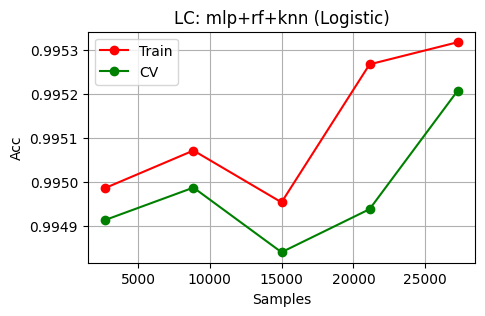

  -> (2) Tuning Meta Model (DecisionTree)...
  -> (3) Final Prediction... 

/home/yc54616/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Done. (Acc: 0.4970)
     [Metrics] P: 0.4144, R: 0.4970, F1: 0.4259
    📊 Drawing Meta-Learning Curve for mlp+rf+knn (DecisionTree)...


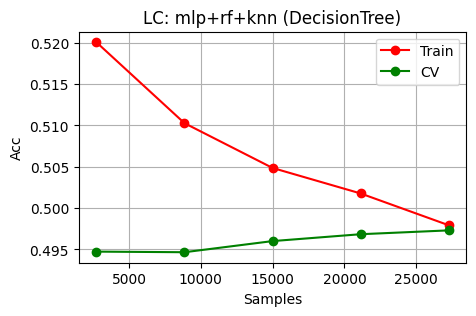

  -> (2) Tuning Meta Model (KNN)...
  -> (3) Final Prediction... Done. (Acc: 0.9945)
     [Metrics] P: 0.9945, R: 0.9945, F1: 0.9945
    📊 Drawing Meta-Learning Curve for mlp+rf+knn (KNN)...


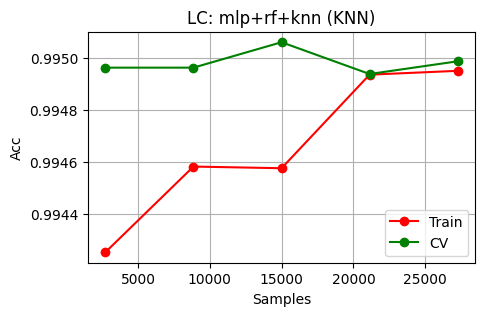


[3 Models Combo] mlp+rf+gb
Done.(1) Generating Meta Features... 
  -> (2) Tuning Meta Model (Logistic)...
  -> (3) Final Prediction... Done. (Acc: 0.9939)
     [Metrics] P: 0.9939, R: 0.9939, F1: 0.9939
    📊 Drawing Meta-Learning Curve for mlp+rf+gb (Logistic)...


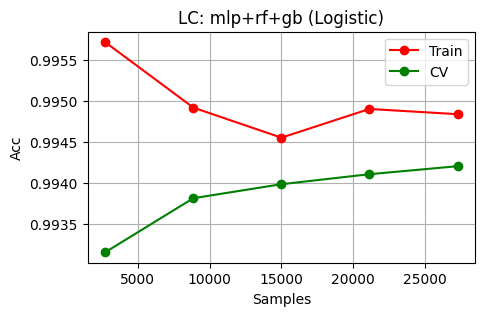

  -> (2) Tuning Meta Model (DecisionTree)...
  -> (3) Final Prediction... 

/home/yc54616/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Done. (Acc: 0.4974)
     [Metrics] P: 0.4140, R: 0.4974, F1: 0.4259
    📊 Drawing Meta-Learning Curve for mlp+rf+gb (DecisionTree)...


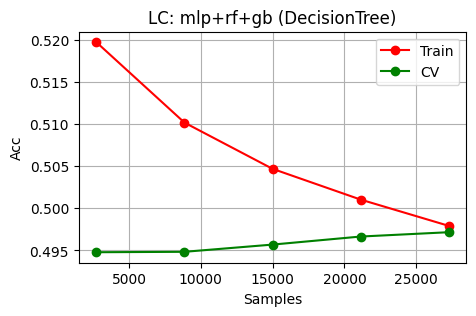

  -> (2) Tuning Meta Model (KNN)...
  -> (3) Final Prediction... Done. (Acc: 0.9924)
     [Metrics] P: 0.9924, R: 0.9924, F1: 0.9924
    📊 Drawing Meta-Learning Curve for mlp+rf+gb (KNN)...


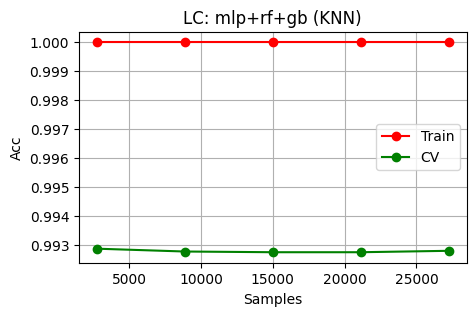


[3 Models Combo] mlp+knn+gb
Done.(1) Generating Meta Features... 
  -> (2) Tuning Meta Model (Logistic)...
  -> (3) Final Prediction... Done. (Acc: 0.9940)
     [Metrics] P: 0.9940, R: 0.9940, F1: 0.9940
    📊 Drawing Meta-Learning Curve for mlp+knn+gb (Logistic)...


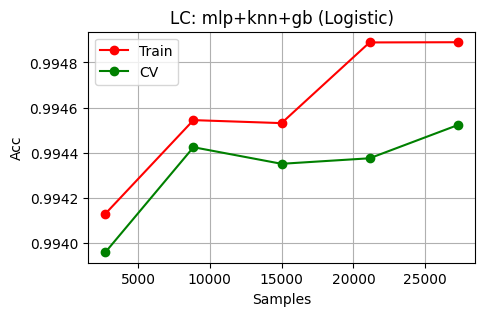

  -> (2) Tuning Meta Model (DecisionTree)...
  -> (3) Final Prediction... 

/home/yc54616/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Done. (Acc: 0.4970)
     [Metrics] P: 0.4144, R: 0.4970, F1: 0.4259
    📊 Drawing Meta-Learning Curve for mlp+knn+gb (DecisionTree)...


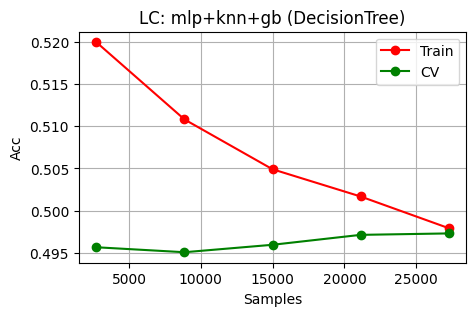

  -> (2) Tuning Meta Model (KNN)...
  -> (3) Final Prediction... Done. (Acc: 0.9940)
     [Metrics] P: 0.9940, R: 0.9940, F1: 0.9940
    📊 Drawing Meta-Learning Curve for mlp+knn+gb (KNN)...


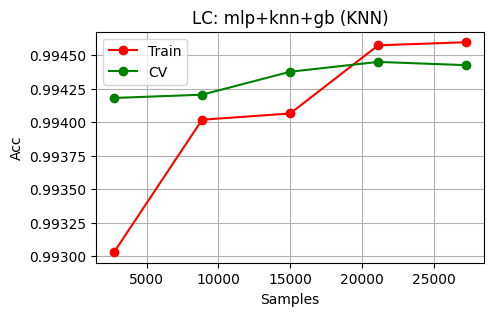


[3 Models Combo] rf+knn+gb
Done.(1) Generating Meta Features... 
  -> (2) Tuning Meta Model (Logistic)...
  -> (3) Final Prediction... Done. (Acc: 0.9933)
     [Metrics] P: 0.9934, R: 0.9933, F1: 0.9933
    📊 Drawing Meta-Learning Curve for rf+knn+gb (Logistic)...


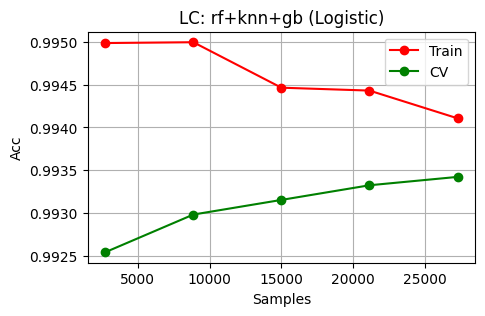

  -> (2) Tuning Meta Model (DecisionTree)...
  -> (3) Final Prediction... 

/home/yc54616/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Done. (Acc: 0.4978)
     [Metrics] P: 0.4896, R: 0.4978, F1: 0.4269
    📊 Drawing Meta-Learning Curve for rf+knn+gb (DecisionTree)...


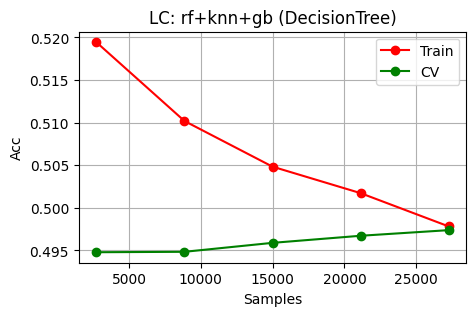

  -> (2) Tuning Meta Model (KNN)...
  -> (3) Final Prediction... Done. (Acc: 0.9930)
     [Metrics] P: 0.9930, R: 0.9930, F1: 0.9930
    📊 Drawing Meta-Learning Curve for rf+knn+gb (KNN)...


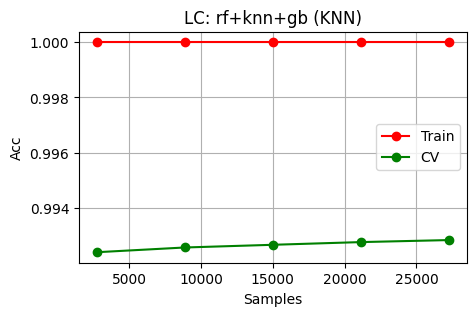


[4 Models Combo] mlp+rf+knn+gb
Done.(1) Generating Meta Features... 
  -> (2) Tuning Meta Model (Logistic)...
  -> (3) Final Prediction... Done. (Acc: 0.9948)
     [Metrics] P: 0.9948, R: 0.9948, F1: 0.9948
    📊 Drawing Meta-Learning Curve for mlp+rf+knn+gb (Logistic)...


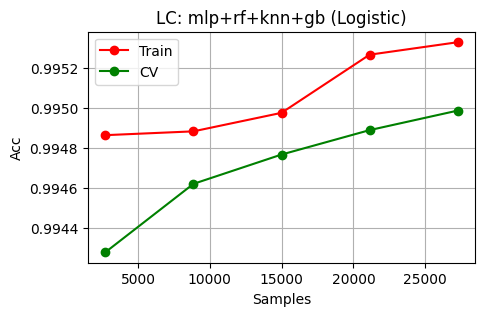

  -> (2) Tuning Meta Model (DecisionTree)...
  -> (3) Final Prediction... 

/home/yc54616/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Done. (Acc: 0.4970)
     [Metrics] P: 0.4144, R: 0.4970, F1: 0.4259
    📊 Drawing Meta-Learning Curve for mlp+rf+knn+gb (DecisionTree)...


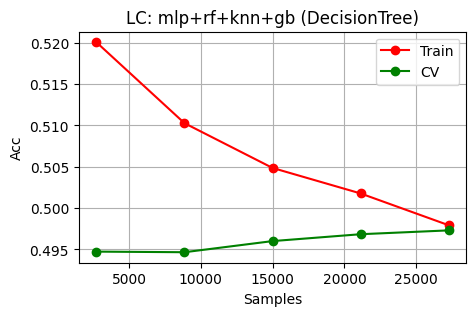

  -> (2) Tuning Meta Model (KNN)...
  -> (3) Final Prediction... Done. (Acc: 0.9945)
     [Metrics] P: 0.9945, R: 0.9945, F1: 0.9945
    📊 Drawing Meta-Learning Curve for mlp+rf+knn+gb (KNN)...


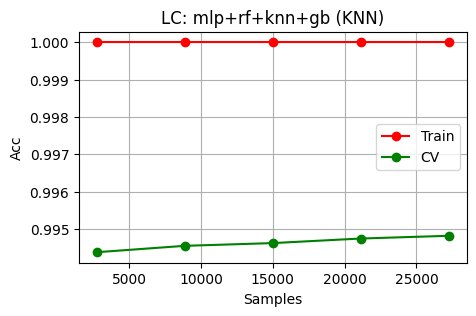

In [8]:
import joblib
import numpy as np
import time
import os
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import mode
import warnings

# 경고 무시
warnings.simplefilter(action='ignore', category=FutureWarning)

# Scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from scipy.ndimage import zoom

# =========================================================
# 1. 헬퍼 클래스 (수정됨: classes_ 속성 위임 추가)
# =========================================================
class ForceFittedClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator):
        self.estimator = estimator
        
    def fit(self, X, y=None): 
        return self
        
    def predict(self, X): 
        return self.estimator.predict(X)
        
    def predict_proba(self, X): 
        return self.estimator.predict_proba(X)
    
    # 🔥 [중요] StackingClassifier가 원본 모델의 클래스 정보를 참조할 수 있게 함
    @property
    def classes_(self):
        return self.estimator.classes_
        
    def __sklearn_is_fitted__(self): 
        return True

# ... (CustomImagePreprocess, PreFittedVotingClassifier 등은 기존과 동일하므로 생략하거나 그대로 둡니다) ...
class CustomImagePreprocess(BaseEstimator, TransformerMixin):
    def __init__(self, stroke_target=0.4, target_size=20, final_size=28, noise_threshold=0.02):
        self.stroke_target = stroke_target       
        self.target_size = target_size           
        self.final_size = final_size             
        self.noise_threshold = noise_threshold   
    def fit(self, X, y=None): return self
    def transform(self, X, y=None):
        X = np.array(X)
        if X.ndim == 2:
            side = int(np.sqrt(X.shape[1]))
            X = X.reshape(-1, side, side)
        processed = []
        for img in X:
            img = self.normalize_scale(img)   
            img = self.remove_noise(img)      
            img = self.normalize_stroke(img)  
            img = self.normalize_size(img)    
            img = self.center_align(img)
            processed.append(img)
        processed = np.array(processed)
        return processed.reshape(len(processed), -1)
    def normalize_scale(self, img): return (img.astype(np.float32) / 255.0) if img.max() > 1 else img.astype(np.float32)
    def remove_noise(self, img): img[img < self.noise_threshold] = 0.0; return img
    def normalize_stroke(self, img):
        mask = img > 0.05
        if mask.sum() == 0: return img
        mean_val = img[mask].mean()
        scale = self.stroke_target / mean_val if mean_val > 0 else 1
        return np.clip(img * scale, 0, 1)
    def normalize_size(self, img):
        coords = np.where(img > 0.05)
        if coords[0].size == 0: return np.zeros((self.final_size, self.final_size))
        r1, r2, c1, c2 = coords[0].min(), coords[0].max(), coords[1].min(), coords[1].max()
        digit = img[r1:r2+1, c1:c2+1]
        h, w = digit.shape
        if h==0 or w==0: return np.zeros((self.final_size, self.final_size))
        return zoom(digit, (self.target_size/h, self.target_size/w))
    def center_align(self, img):
        canvas = np.zeros((self.final_size, self.final_size))
        h, w = img.shape
        y, x = (self.final_size-h)//2, (self.final_size-w)//2
        canvas[y:y+h, x:x+w] = img
        return canvas

class PreFittedVotingClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, estimators, voting='soft'):
        self.estimators = estimators
        self.voting = voting
    def fit(self, X, y): return self
    def predict(self, X):
        if self.voting == 'soft': return np.argmax(self.predict_proba(X), axis=1)
        predictions = np.column_stack([m.predict(X) for _, m in self.estimators])
        return mode(predictions, axis=1).mode.flatten()
    def predict_proba(self, X):
        if self.voting == 'hard': raise AttributeError("No predict_proba for hard voting")
        probas = [m.predict_proba(X) for _, m in self.estimators]
        return np.mean(probas, axis=0)

# =========================================================
# 데이터 로드
# =========================================================
def load_data_simple(hand_path, org_path):
    print("📂 Loading Data...")
    if not os.path.exists(hand_path) or not os.path.exists(org_path): return None, None, None, None
    d_hand = np.load(hand_path, allow_pickle=True)
    X_hand, y_hand = d_hand['x_train'], d_hand['y_train'].astype(int)
    d_org = np.load(org_path, allow_pickle=True)
    X_org, y_org = d_org['x_train'], d_org['y_train'].astype(int)
    X = np.concatenate([X_hand.reshape(len(X_hand), -1), X_org.reshape(len(X_org), -1)])
    y = np.concatenate([y_hand, y_org])
    if X.max() > 1.0: X = X.astype(np.float32) / 255.0
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# =========================================================
# 📝 Meta Model Learning Curve
# =========================================================
def plot_meta_learning_curve(estimator, title, X_meta, y, cv=3):
    print(f"    📊 Drawing Meta-Learning Curve for {title}...")
    try:
        # n_jobs=1로 설정하여 안전하게 그림
        train_sizes, train_scores, test_scores = learning_curve(
            estimator, X_meta, y, cv=cv, scoring='accuracy', n_jobs=1, 
            train_sizes=np.linspace(0.1, 1.0, 5) 
        )
        
        train_mean = np.mean(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        
        plt.figure(figsize=(5, 3))
        plt.plot(train_sizes, train_mean, 'o-', color="r", label="Train")
        plt.plot(train_sizes, test_mean, 'o-', color="g", label="CV")
        plt.title(f"LC: {title}")
        plt.xlabel("Samples")
        plt.ylabel("Acc")
        plt.legend()
        plt.grid()
        plt.show()
    except Exception as e:
        print(f"    [Warning] Skipping Learning Curve: {e}")

# =========================================================
# 메인 실행
# =========================================================
if __name__ == "__main__":
    hand_file = '../data/final/mnist_final_balanced.npz'
    org_file = '../data/final/mnist_sklearn_40000.npz'
    X_train, X_test, y_train, y_test = load_data_simple(hand_file, org_file)

    if X_train is not None:
        model_paths = {
            'mlp': 'pipeline/base/mlp_HandAug_4x.joblib',
            'rf':  'pipeline/base/pipeline_model_HandAug_4x_Preprocessed_rf.pkl',
            'knn': 'pipeline/base/pipeline_knn_model_HandAug_4x_Preprocessed_KNN.pkl',
            'gb':  'pipeline/base/pipeline_model_HandAug_1x_Preprocessed_gb.pkl',
        }
        
        loaded_estimators = {}
        print("\n📂 Loading Base Models...")
        for name, path in model_paths.items():
            if os.path.exists(path):
                try:
                    loaded_model = joblib.load(path)
                    wrapped_model = ForceFittedClassifier(loaded_model) # 수정된 Wrapper 사용
                    loaded_estimators[name] = wrapped_model
                    print(f"  > Loaded & Wrapped: {name}")
                except Exception as e:
                    print(f"  [Error] Failed to load {name}: {e}")
            else:
                print(f"  [Warning] Not found: {path}")
        
        available_models = list(loaded_estimators.items())
        
        meta_configs = {
            'Logistic': {
                'model': LogisticRegression(random_state=42, max_iter=1000),
                'params': {'C': [0.1, 1.0, 10.0], 'solver': ['lbfgs', 'liblinear']}
            },
            'DecisionTree': {
                'model': DecisionTreeClassifier(random_state=42),
                'params': {'max_depth': [3, 4], 'min_samples_leaf': [10, 20]}
            },
            'KNN': {
                'model': KNeighborsClassifier(),
                'params': {'n_neighbors': [9, 15, 30], 'weights': ['uniform', 'distance']}
            }
        }

        if len(available_models) >= 3:
            results = []
            
            for k in range(3, min(5, len(available_models)) + 1):
                for combo in combinations(available_models, k):
                    combo_names = "+".join([name for name, _ in combo])
                    estimators_list = list(combo)
                    
                    print(f"\n[{k} Models Combo] {combo_names}")
                    
                    # -----------------------------------------------------
                    # (A) Stacking
                    # -----------------------------------------------------
                    try:
                        print("  -> (1) Generating Meta Features...", end=" ")
                        # 🔥 수정: n_jobs=None (단일 프로세스) 사용하여 오류 방지
                        temp_stack = StackingClassifier(estimators=estimators_list, final_estimator=LogisticRegression(), cv='prefit', n_jobs=None)
                        temp_stack.fit(X_train, y_train)
                        X_meta_train = temp_stack.transform(X_train)
                        print("Done.")
                        
                        for meta_name, config in meta_configs.items():
                            print(f"  -> (2) Tuning Meta Model ({meta_name})...")
                            # 🔥 수정: n_jobs=None
                            grid = GridSearchCV(config['model'], config['params'], cv=3, scoring='accuracy', n_jobs=None)
                            start = time.time()
                            grid.fit(X_meta_train, y_train)
                            elapsed = time.time() - start
                            
                            best_meta = grid.best_estimator_
                            
                            print("  -> (3) Final Prediction...", end=" ")
                            final_stack = StackingClassifier(
                                estimators=estimators_list,
                                final_estimator=best_meta,
                                cv='prefit',
                                n_jobs=None # 🔥 중요
                            )
                            final_stack.fit(X_train, y_train)
                            
                            y_pred = final_stack.predict(X_test)
                            acc = accuracy_score(y_test, y_pred)
                            f1 = f1_score(y_test, y_pred, average='weighted')
                            prec = precision_score(y_test, y_pred, average='weighted')
                            rec = recall_score(y_test, y_pred, average='weighted')
                            
                            print(f"Done. (Acc: {acc:.4f})")
                            print(f"     [Metrics] P: {prec:.4f}, R: {rec:.4f}, F1: {f1:.4f}")

                            plot_meta_learning_curve(best_meta, f"{combo_names} ({meta_name})", X_meta_train, y_train)
                            
                            results.append({'Type': 'Stacking', 'Base': combo_names, 'Meta': meta_name, 'Acc': acc, 'F1': f1})

                    except Exception as e:
                        import traceback
                        print(f"\n  [Error] Stacking failed: {e}")
                        # traceback.print_exc() # 상세 오류 필요시 주석 해제